# Taxi-v4: Q-learning vs DQN Analysis

Compare tabular Q-learning and shallow DQN on [Gymnasium Taxi-v4](https://gymnasium.farama.org/environments/toy_text/taxi/).

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path('..').resolve()
RESULTS = ROOT / 'results'

## Load baseline runs

In [2]:
def load_metrics(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df['rolling_reward'] = df['reward'].rolling(100, min_periods=1).mean()
    return df

ql_metrics = load_metrics(RESULTS / 'q_learning' / 'baseline' / 'metrics.csv')
dqn_metrics = load_metrics(RESULTS / 'dqn' / 'baseline' / 'metrics.csv')

with open(RESULTS / 'q_learning' / 'baseline' / 'summary.json') as f:
    ql_summary = json.load(f)
with open(RESULTS / 'dqn' / 'baseline' / 'summary.json') as f:
    dqn_summary = json.load(f)

ql_summary, dqn_summary

({'final_avg_reward': 6.63,
  'final_success_rate': 0.98,
  'avg_steps_success': 14.316202712348323,
  'total_episodes': 15000,
  'training_time_sec': 4.859046165947802,
  'eval': {'mean_reward': 7.34, 'mean_steps': 13.66, 'success_rate': 1.0}},
 {'final_avg_reward': 7.02,
  'final_success_rate': 1.0,
  'avg_steps_success': 14.7629886194953,
  'total_episodes': 4000,
  'training_time_sec': 25.502155374968424,
  'eval': {'mean_reward': 3.32, 'mean_steps': 17.26, 'success_rate': 0.98}})

## Learning curves

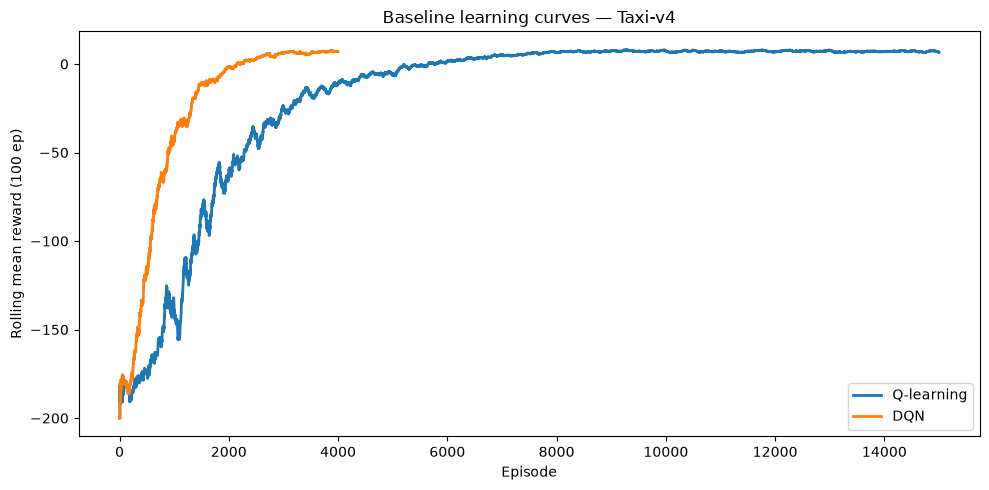

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ql_metrics['episode'], ql_metrics['rolling_reward'], label='Q-learning', linewidth=2)
ax.plot(dqn_metrics['episode'], dqn_metrics['rolling_reward'], label='DQN', linewidth=2)
ax.set_xlabel('Episode')
ax.set_ylabel('Rolling mean reward (100 ep)')
ax.set_title('Baseline learning curves — Taxi-v4')
ax.legend()
fig.tight_layout()
plt.show()

## Baseline comparison

In [4]:
comparison = pd.DataFrame({
    'Metric': [
        'Final avg reward (last 100 ep)',
        'Final success rate (last 100 ep)',
        'Eval mean reward',
        'Eval success rate',
        'Avg steps (successful ep)',
        'Training time (s)',
        'Total episodes',
    ],
    'Q-learning': [
        ql_summary['final_avg_reward'],
        ql_summary['final_success_rate'],
        ql_summary['eval']['mean_reward'],
        ql_summary['eval']['success_rate'],
        ql_summary['avg_steps_success'],
        ql_summary['training_time_sec'],
        ql_summary['total_episodes'],
    ],
    'DQN': [
        dqn_summary['final_avg_reward'],
        dqn_summary['final_success_rate'],
        dqn_summary['eval']['mean_reward'],
        dqn_summary['eval']['success_rate'],
        dqn_summary['avg_steps_success'],
        dqn_summary['training_time_sec'],
        dqn_summary['total_episodes'],
    ],
})
comparison

,Metric,Q-learning,DQN
0,Final avg reward (last 100 ep),6.630000,7.020000
1,Final success rate (last 100 ep),0.980000,1.000000
2,Eval mean reward,7.340000,3.320000
3,Eval success rate,1.000000,0.980000
4,Avg steps (successful ep),14.316203,14.762989
5,Training time (s),4.859046,25.502155
6,Total episodes,15000.000000,4000.000000


## Hyperparameter sweep

In [5]:
sweep_path = RESULTS / 'sweep_summary.csv'
if sweep_path.exists():
    sweep = pd.read_csv(sweep_path)
    display(sweep.sort_values(['algo', 'final_avg_reward'], ascending=[True, False]).head(10))
else:
    print('Run: python scripts/sweep_hyperparams.py')

,algo,run_id,output_dir,alpha,gamma,epsilon_start,epsilon_end,decay_episodes,n_states,n_actions,...,eval_success_rate,hidden_size,dropout,lr,weight_decay,batch_size,buffer_capacity,min_buffer_size,target_update_freq,train_freq
10,dqn,dqn_lr_0.001,/Users/luisguareschi/Documents/IEMaster/ie-rei...,NaN,0.99,1.0,0.05,3000,500,6,...,0.96,64.0,0.0,0.0010,0.0001,128.0,10000.0,256.0,500.0,4.0
11,dqn,dqn_wd_0.0,/Users/luisguareschi/Documents/IEMaster/ie-rei...,NaN,0.99,1.0,0.05,3000,500,6,...,1.00,64.0,0.0,0.0005,0.0000,128.0,10000.0,256.0,500.0,4.0
16,dqn,dqn_hidden_256,/Users/luisguareschi/Documents/IEMaster/ie-rei...,NaN,0.99,1.0,0.05,3000,500,6,...,1.00,256.0,0.0,0.0005,0.0001,128.0,10000.0,256.0,500.0,4.0
9,dqn,dqn_lr_0.0005,/Users/luisguareschi/Documents/IEMaster/ie-rei...,NaN,0.99,1.0,0.05,3000,500,6,...,0.98,64.0,0.0,0.0005,0.0001,128.0,10000.0,256.0,500.0,4.0
12,dqn,dqn_wd_0.0001,/Users/luisguareschi/Documents/IEMaster/ie-rei...,NaN,0.99,1.0,0.05,3000,500,6,...,0.98,64.0,0.0,0.0005,0.0001,128.0,10000.0,256.0,500.0,4.0
14,dqn,dqn_hidden_64,/Users/luisguareschi/Documents/IEMaster/ie-rei...,NaN,0.99,1.0,0.05,3000,500,6,...,0.98,64.0,0.0,0.0005,0.0001,128.0,10000.0,256.0,500.0,4.0
8,dqn,dqn_lr_0.0001,/Users/luisguareschi/Documents/IEMaster/ie-rei...,NaN,0.99,1.0,0.05,3000,500,6,...,0.94,64.0,0.0,0.0001,0.0001,128.0,10000.0,256.0,500.0,4.0
13,dqn,dqn_wd_0.001,/Users/luisguareschi/Documents/IEMaster/ie-rei...,NaN,0.99,1.0,0.05,3000,500,6,...,1.00,64.0,0.0,0.0005,0.0010,128.0,10000.0,256.0,500.0,4.0
15,dqn,dqn_hidden_128,/Users/luisguareschi/Documents/IEMaster/ie-rei...,NaN,0.99,1.0,0.05,3000,500,6,...,1.00,128.0,0.0,0.0005,0.0001,128.0,10000.0,256.0,500.0,4.0
0,q_learning,ql_alpha_0.1,/Users/luisguareschi/Documents/IEMaster/ie-rei...,0.1,0.99,1.0,0.05,2500,500,6,...,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


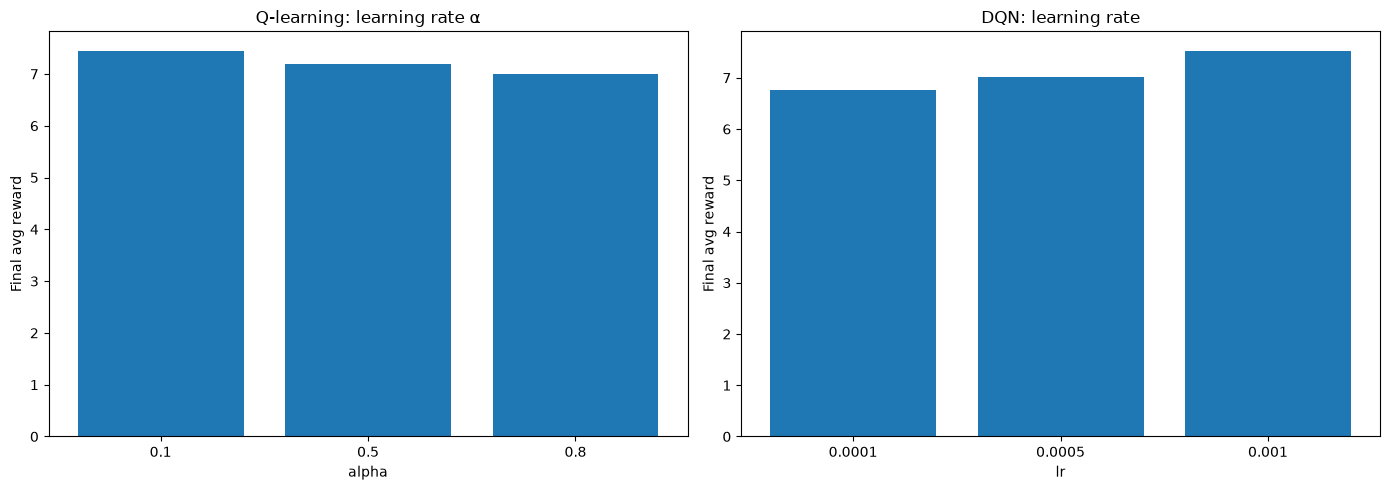

In [6]:
if sweep_path.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ql = sweep[sweep['algo'] == 'q_learning']
    if 'alpha' in ql.columns:
        ql_alpha = ql[ql['run_id'].str.startswith('ql_alpha')]
        axes[0].bar(ql_alpha['alpha'].astype(str), ql_alpha['final_avg_reward'])
        axes[0].set_title('Q-learning: learning rate α')
        axes[0].set_xlabel('alpha')
        axes[0].set_ylabel('Final avg reward')

    dqn = sweep[sweep['algo'] == 'dqn']
    dqn_lr = dqn[dqn['run_id'].str.startswith('dqn_lr')]
    axes[1].bar(dqn_lr['lr'].astype(str), dqn_lr['final_avg_reward'])
    axes[1].set_title('DQN: learning rate')
    axes[1].set_xlabel('lr')
    axes[1].set_ylabel('Final avg reward')

    fig.tight_layout()
    plt.show()

## Key takeaways

1. **Tabular Q-learning** fits Taxi well: 500 discrete states map directly to a Q-table with no approximation error.
2. **DQN** can match training performance but needs masked bootstrap targets (invalid actions otherwise inflate Q-values).
3. **Sample efficiency**: Q-learning converges in fewer episodes; DQN needs replay + more steps but scales to larger state spaces.
4. **Hyperparameters**: α and ε-decay matter most for Q-learning; lr and weight decay matter most for DQN.